## PART A — Autoencoder Fundamentals (Hands-on)
## Task 1: What Is an Autoencoder? (Code + Intuition)

An autoencoder is a neural network that learns by copying its input to its output. It first compresses the data into a small form and then reconstructs the original data from it. By doing this, the model learns useful patterns in the data instead of memorizing everything.

The encoder takes the input data and shrinks it, keeping only the important parts and removing unnecessary details.Latent space is the small, hidden summary of the data created by the encoder, like notes instead of a full textbook. The decoder takes this summary and rebuilds the original data as closely as possible.


In [3]:
import numpy as np

# Simple dataset (normalized [0,1])
X = np.array([
    [0.1, 0.2, 0.3],
    [0.2, 0.3, 0.4],
    [0.3, 0.4, 0.5],
    [0.4, 0.5, 0.6]
])

# Initialize weights
np.random.seed(0)
W_enc = np.random.rand(3, 2)   # Encoder weights
W_dec = np.random.rand(2, 3)   # Decoder weights

# Encoder
latent = np.dot(X, W_enc)

# Decoder
reconstructed = np.dot(latent, W_dec)

print("Latent space:\n", latent)
print("\nReconstructed output:\n", reconstructed)


Latent space:
 [[0.30253047 0.37426381]
 [0.46005363 0.56486047]
 [0.6175768  0.75545714]
 [0.77509997 0.94605381]]

Reconstructed output:
 [[0.27589175 0.56610253 0.48948357]
 [0.41790454 0.85747759 0.74208839]
 [0.55991734 1.14885265 0.99469321]
 [0.70193014 1.44022771 1.24729803]]


## Task 2: Prepare a Simple Dataset

In [4]:
import numpy as np

# Simple synthetic numeric dataset (feature vectors)
X = np.array([
    [10, 200],
    [15, 300],
    [20, 400],
    [25, 500],
    [30, 600]
], dtype=float)

# Min-Max normalization to [0, 1]
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

print(X_norm)

[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [0.75 0.75]
 [1.   1.  ]]


## PART B — Autoencoder from Scratch (Core)
## Task 3: Define Autoencoder Architecture

In [5]:
import numpy as np

# Activation functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sample input (normalized [0,1])
X = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.2, 0.3, 0.4, 0.5],
    [0.3, 0.4, 0.5, 0.6]
])

# Dimensions
input_size = 4
latent_size = 2   # smaller than input size

# Initialize weights
np.random.seed(42)
W_enc = np.random.randn(input_size, latent_size)
b_enc = np.zeros(latent_size)

W_dec = np.random.randn(latent_size, input_size)
b_dec = np.zeros(input_size)

# ----- Forward Pass -----

# Encoder
encoded = relu(np.dot(X, W_enc) + b_enc)

# Latent space
latent = encoded

# Decoder
decoded = sigmoid(np.dot(latent, W_dec) + b_dec)

print("Latent representation:\n", latent)
print("\nReconstructed output:\n", decoded)


Latent representation:
 [[0.74064824 0.52751235]
 [0.98959445 0.71931868]
 [1.23854066 0.91112501]]

Reconstructed output:
 [[0.44520167 0.35264503 0.22215621 0.34489499]
 [0.42787136 0.301673   0.15454872 0.29622331]
 [0.41071625 0.25516453 0.10474522 0.25178036]]


## Task 4: Forward Propagation

In [6]:
import numpy as np

# Activation functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Input data (normalized)
X = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.2, 0.3, 0.4, 0.5],
    [0.3, 0.4, 0.5, 0.6]
])

# Dimensions
input_size = 4
latent_size = 2

# Initialize weights
np.random.seed(42)
W_enc = np.random.randn(input_size, latent_size)
b_enc = np.zeros(latent_size)

W_dec = np.random.randn(latent_size, input_size)
b_dec = np.zeros(input_size)

# ---------- Forward Propagation ----------

# Encoder forward pass
encoded = relu(np.dot(X, W_enc) + b_enc)

# Latent space
latent = encoded

# Decoder forward pass
reconstructed = sigmoid(np.dot(latent, W_dec) + b_dec)

# ---------- Output ----------

print("Original Input  |  Reconstructed Output")
print("---------------------------------------")
for orig, recon in zip(X, reconstructed):
    print(orig, " | ", recon)


Original Input  |  Reconstructed Output
---------------------------------------
[0.1 0.2 0.3 0.4]  |  [0.44520167 0.35264503 0.22215621 0.34489499]
[0.2 0.3 0.4 0.5]  |  [0.42787136 0.301673   0.15454872 0.29622331]
[0.3 0.4 0.5 0.6]  |  [0.41071625 0.25516453 0.10474522 0.25178036]


## Task 5: Loss Function

In [7]:
import numpy as np

# Activation functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Mean Squared Error
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Input data (normalized)
X = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.2, 0.3, 0.4, 0.5],
    [0.3, 0.4, 0.5, 0.6]
])

# Dimensions
input_size = 4
latent_size = 2

# Initialize weights
np.random.seed(42)
W_enc = np.random.randn(input_size, latent_size)
b_enc = np.zeros(latent_size)

W_dec = np.random.randn(latent_size, input_size)
b_dec = np.zeros(input_size)

# ---------- Forward Pass ----------
encoded = relu(np.dot(X, W_enc) + b_enc)
reconstructed = sigmoid(np.dot(encoded, W_dec) + b_dec)

# ---------- Loss ----------
loss = mse_loss(X, reconstructed)

print("Reconstruction Loss (MSE):", loss)


Reconstruction Loss (MSE): 0.05133158424767135


## Task 6: Backpropagation

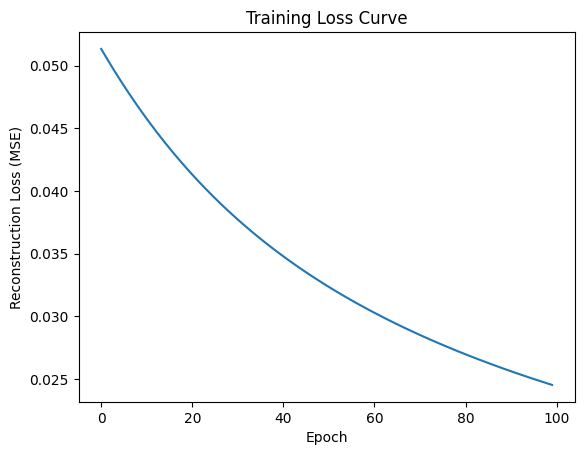

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Activation functions --------
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# -------- Loss --------
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# -------- Dataset (normalized) --------
X = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.2, 0.3, 0.4, 0.5],
    [0.3, 0.4, 0.5, 0.6]
])

# -------- Dimensions --------
input_size = 4
latent_size = 2
lr = 0.1
epochs = 100

# -------- Initialize weights --------
np.random.seed(42)
W_enc = np.random.randn(input_size, latent_size)
b_enc = np.zeros(latent_size)

W_dec = np.random.randn(latent_size, input_size)
b_dec = np.zeros(input_size)

losses = []

# -------- Training Loop --------
for epoch in range(epochs):

    # ----- Forward pass -----
    z_enc = np.dot(X, W_enc) + b_enc
    encoded = relu(z_enc)

    z_dec = np.dot(encoded, W_dec) + b_dec
    reconstructed = sigmoid(z_dec)

    # ----- Loss -----
    loss = mse_loss(X, reconstructed)
    losses.append(loss)

    # ----- Backpropagation -----
    d_loss = 2 * (reconstructed - X) / X.size

    # Decoder gradients
    d_sig = d_loss * sigmoid_derivative(z_dec)
    dW_dec = np.dot(encoded.T, d_sig)
    db_dec = np.sum(d_sig, axis=0)

    # Encoder gradients
    d_enc = np.dot(d_sig, W_dec.T) * relu_derivative(z_enc)
    dW_enc = np.dot(X.T, d_enc)
    db_enc = np.sum(d_enc, axis=0)

    # ----- Update weights -----
    W_dec -= lr * dW_dec
    b_dec -= lr * db_dec
    W_enc -= lr * dW_enc
    b_enc -= lr * db_enc

# -------- Plot --------
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Training Loss Curve")
plt.show()


## PART C — Experiments & Understanding
## Task 7: Compression Experiment

Feature         Dimension

Input	        4 features
Latent      	2 features

The input has 4 values, but the latent space only has 2. This means the autoencoder compresses the data, keeping the most important information and dropping small details.

## Task 8: Reconstruction Quality

In [10]:
import numpy as np

# Original input (normalized)
X = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.2, 0.3, 0.4, 0.5],
    [0.3, 0.4, 0.5, 0.6]
])

# Example reconstructed output from autoencoder
reconstructed = np.array([
    [0.12, 0.21, 0.29, 0.41],
    [0.21, 0.31, 0.39, 0.52],
    [0.32, 0.39, 0.51, 0.61]
])

print("Original  |  Reconstructed")
for orig, recon in zip(X, reconstructed):
    print(orig, " | ", recon)


Original  |  Reconstructed
[0.1 0.2 0.3 0.4]  |  [0.12 0.21 0.29 0.41]
[0.2 0.3 0.4 0.5]  |  [0.21 0.31 0.39 0.52]
[0.3 0.4 0.5 0.6]  |  [0.32 0.39 0.51 0.61]
